In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from bitflip import BitflipDQNTrainer
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
import pandas as pd
import tqdm

In [ ]:
def make_live_plotter(title):
    def _plot(epoch, history):
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        fig.suptitle(title)

        axes[0, 0].plot(history['success_rate'])
        axes[0, 0].set_title('Success Rate')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Rate')

        axes[0, 1].plot(history['avg_episode_len'])
        axes[0, 1].set_title('Avg Episode Length')
        axes[0, 1].set_xlabel('Epoch')

        axes[0, 2].plot(history['avg_q'])
        axes[0, 2].set_title('Avg Q Value')
        axes[0, 2].set_xlabel('Epoch')

        axes[1, 0].plot(history['eval_success_rate'])
        axes[1, 0].set_title('Eval Success Rate')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Rate')

        axes[1, 1].plot(history['eval_avg_episode_len'])
        axes[1, 1].set_title('Eval Avg Episode Length')
        axes[1, 1].set_xlabel('Epoch')


        axes[1, 2].plot(history['avg_loss'])
        axes[1, 2].set_title('TD Loss')
        axes[1, 2].set_xlabel('Epoch')


        for ax in axes.flatten():
            ax.grid()

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        print(f"Epoch {epoch}, Success: {history['eval_success_rate'][-1]:.5f}")
    return _plot

In [ ]:
save_path = "checkpoints/bitflip"
!mkdir -p {save_path}

In [ ]:
epochs = 50
trainers = {}

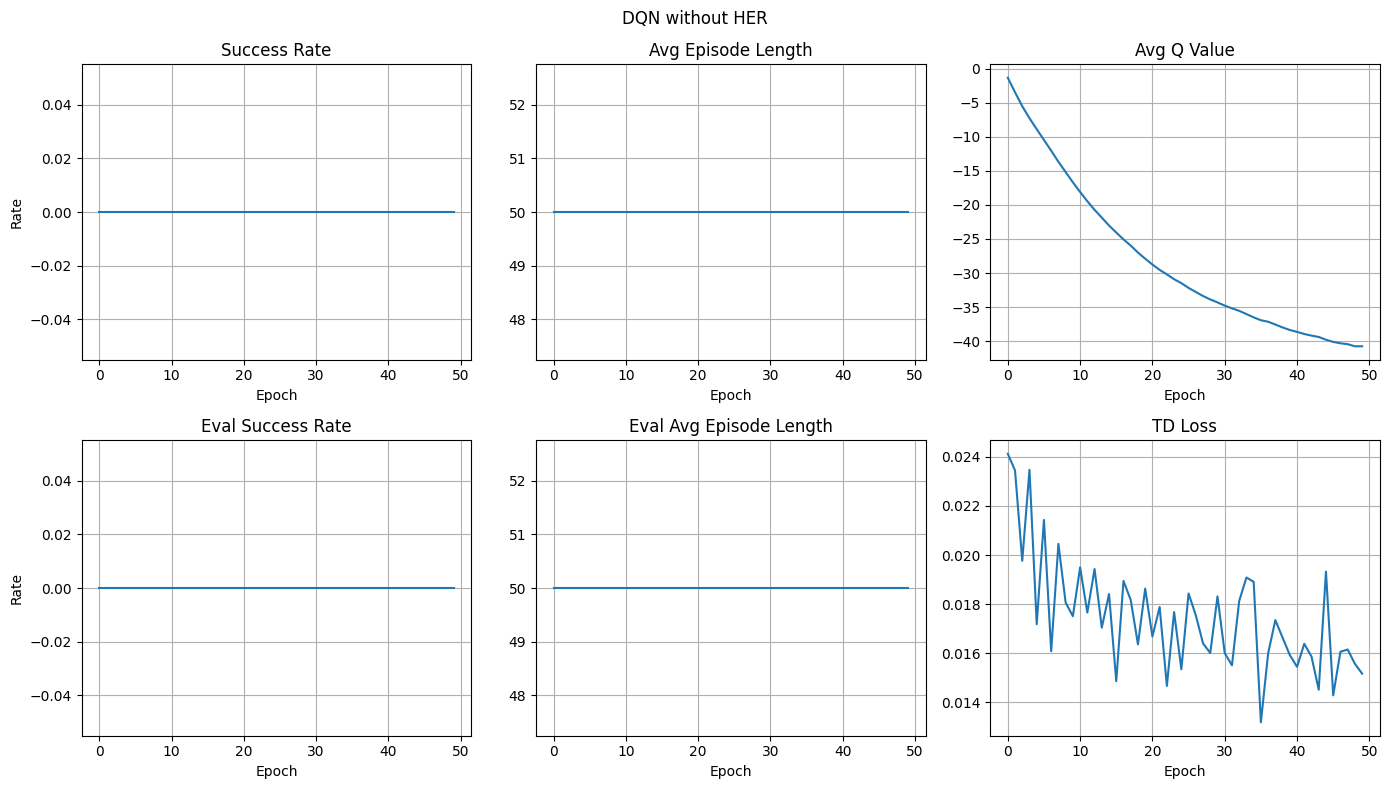

100%|██████████| 50/50 [09:50<00:00, 11.80s/it]

Epoch 49, Success: 0.00000


In [ ]:
trainer = BitflipDQNTrainer(use_her=False)
trainers["no HER"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN without HER'))
trainer.save_model(f"{save_path}/no_her.pth")

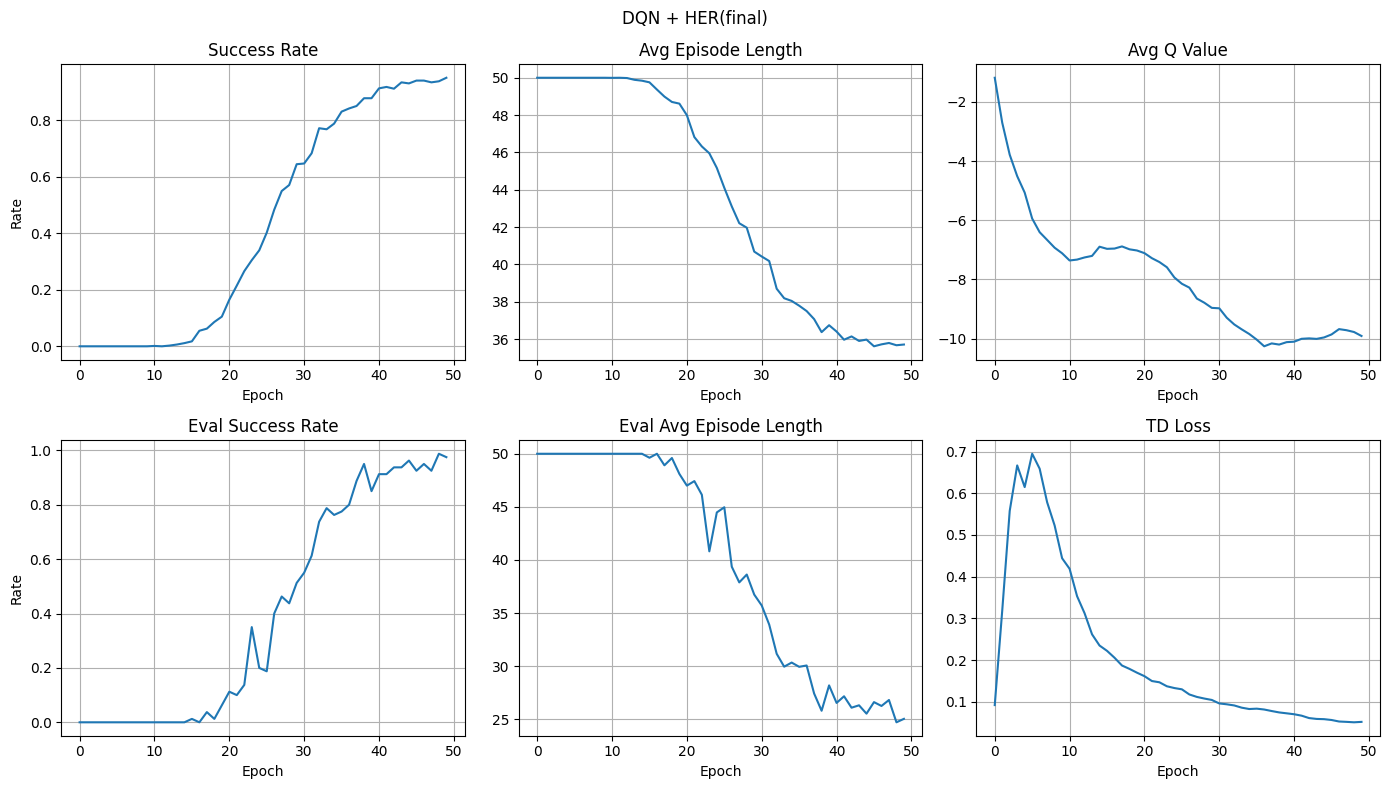

100%|██████████| 50/50 [09:17<00:00, 11.16s/it]

Epoch 49, Success: 0.97500


In [ ]:
trainer = BitflipDQNTrainer(use_her=True, her_strategy='final')
trainers["final"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN + HER(final)'))
trainer.save_model(f"{save_path}/her_final.pth")

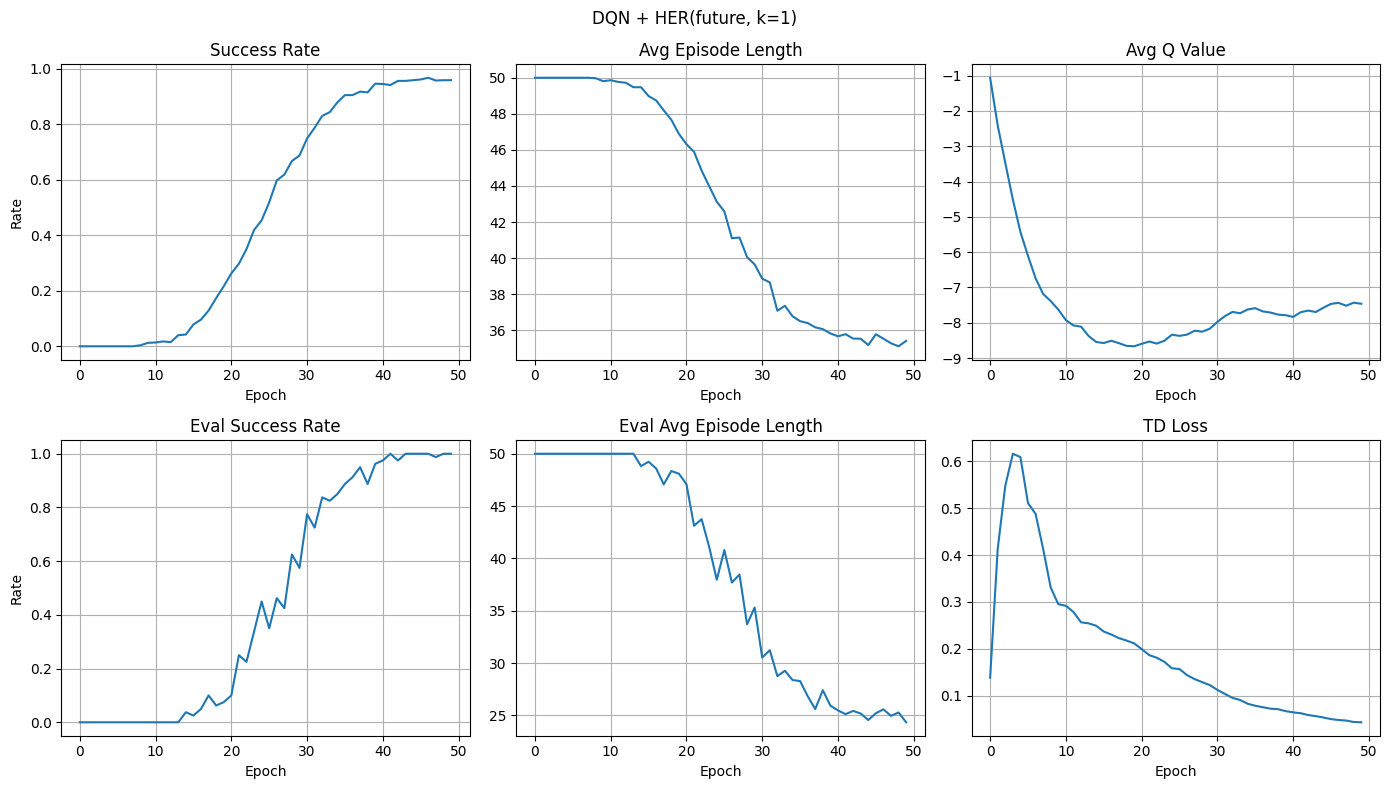

100%|██████████| 50/50 [09:02<00:00, 10.85s/it]

Epoch 49, Success: 1.00000


In [ ]:
trainer = BitflipDQNTrainer(use_her=True, her_strategy='future', her_k=1)
trainers["future, k=1"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN + HER(future, k=1)'))
trainer.save_model(f"{save_path}/her_future_k1.pth")

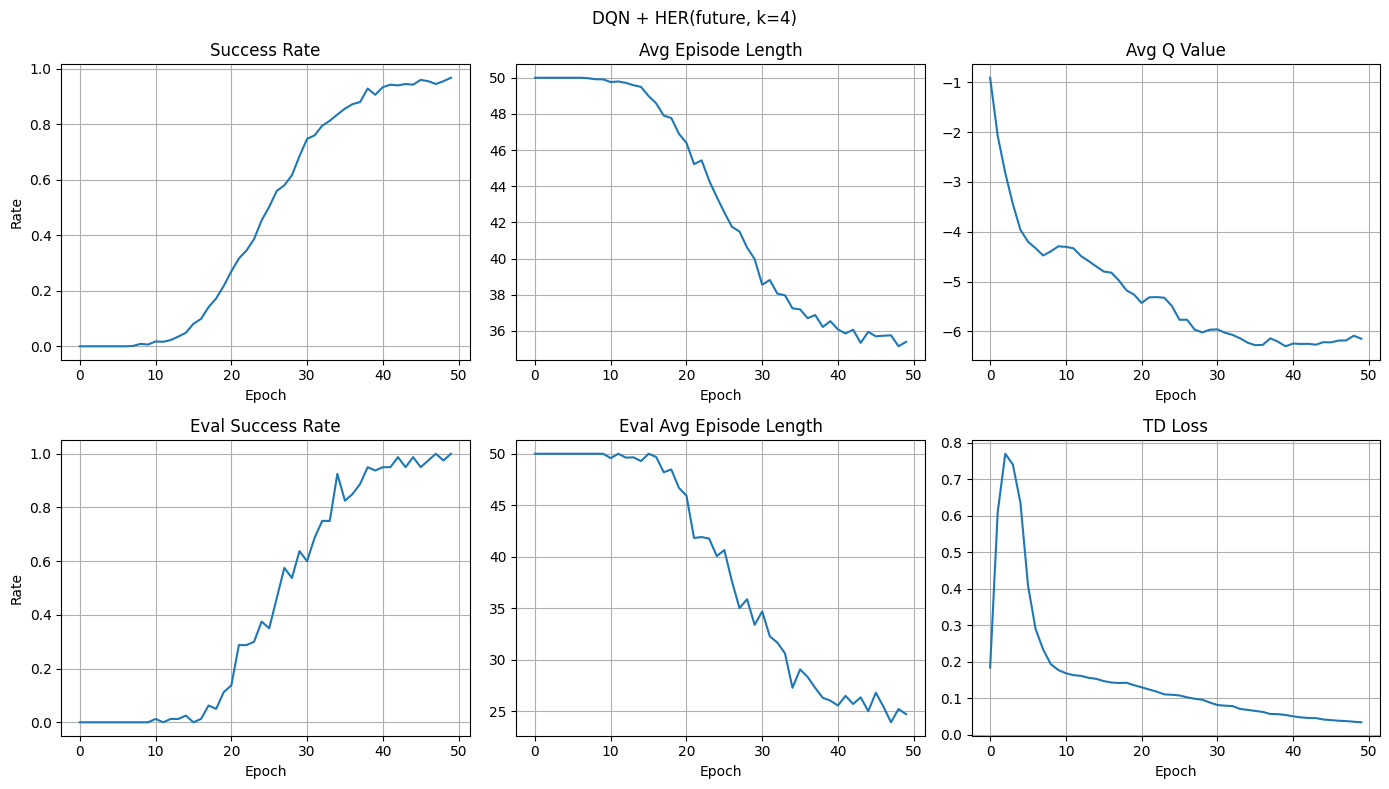

100%|██████████| 50/50 [09:26<00:00, 11.32s/it]

Epoch 49, Success: 1.00000


In [ ]:
trainer = BitflipDQNTrainer(use_her=True, her_strategy='future', her_k=4)
trainers["future, k=4"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN + HER(future, k=4)'))
trainer.save_model(f"{save_path}/her_future_k4.pth")

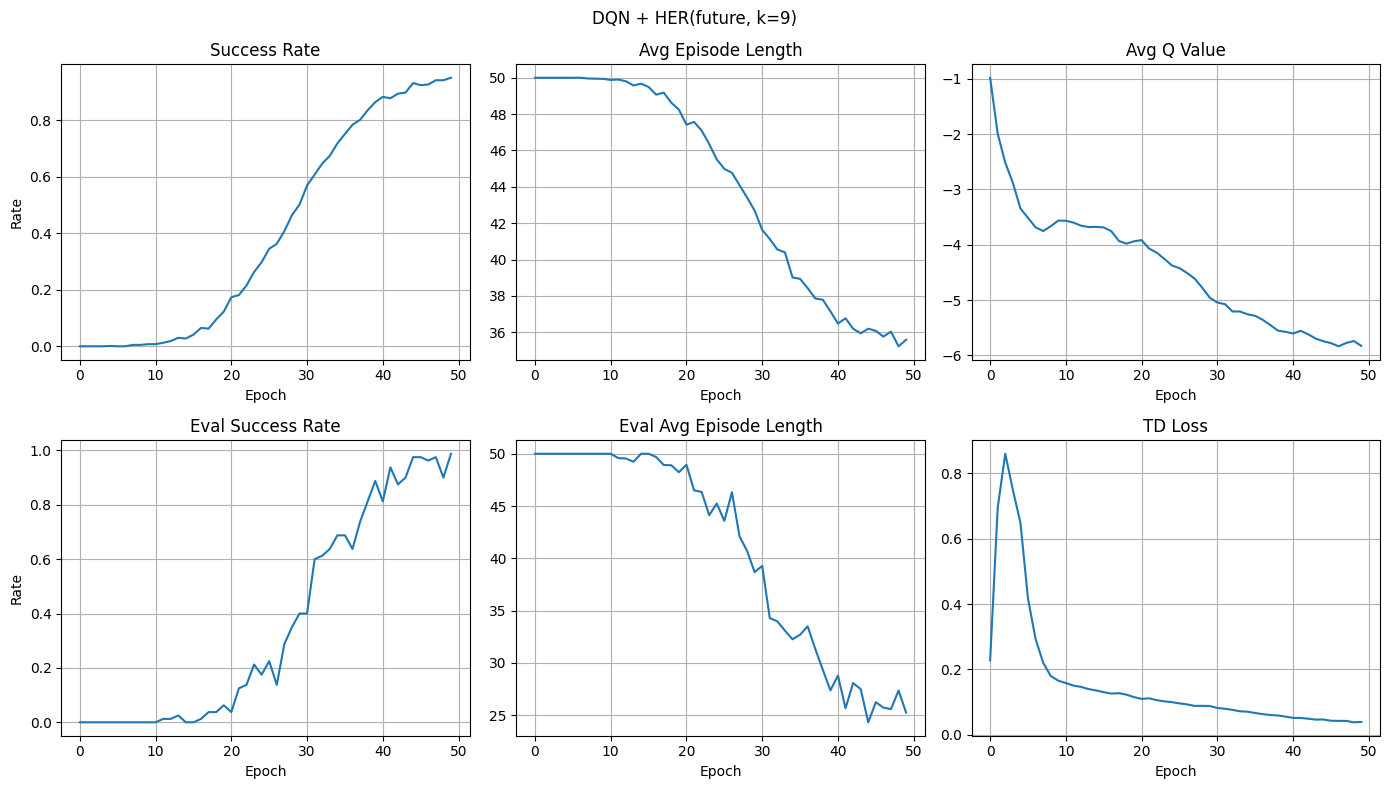

100%|██████████| 50/50 [10:12<00:00, 12.25s/it]

Epoch 49, Success: 0.98750


In [ ]:
trainer = BitflipDQNTrainer(use_her=True, her_strategy='future', her_k=9)
trainers["future, k=9"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN + HER(future, k=9)'))
trainer.save_model(f"{save_path}/her_future_k9.pth")

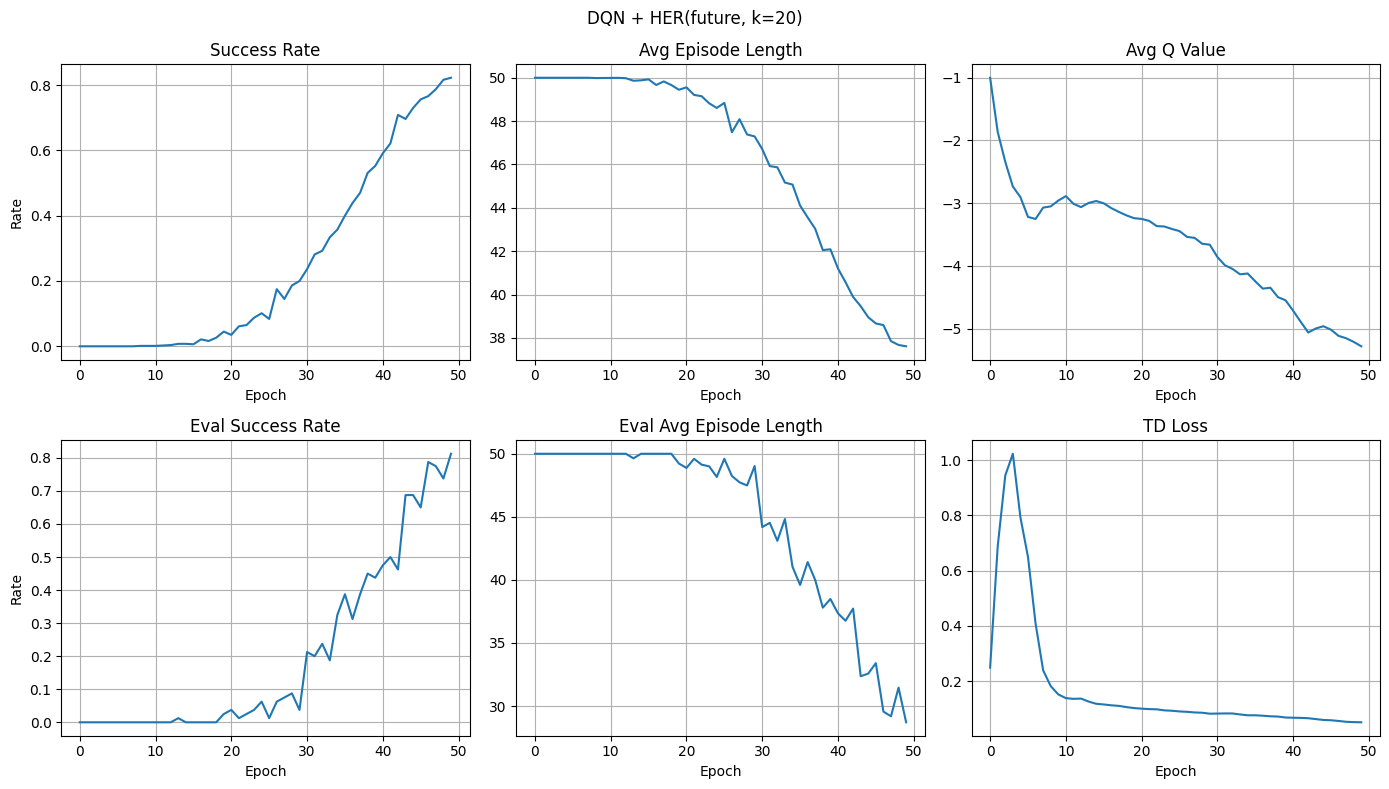

100%|██████████| 50/50 [12:06<00:00, 14.54s/it]

Epoch 49, Success: 0.81250


In [ ]:
trainer = BitflipDQNTrainer(use_her=True, her_strategy='future', her_k=20)
trainers["future, k=20"] = trainer
history = trainer.train(epochs=epochs, log_callback=make_live_plotter('DQN + HER(future, k=20)'))
trainer.save_model(f"{save_path}/her_future_k20.pth")

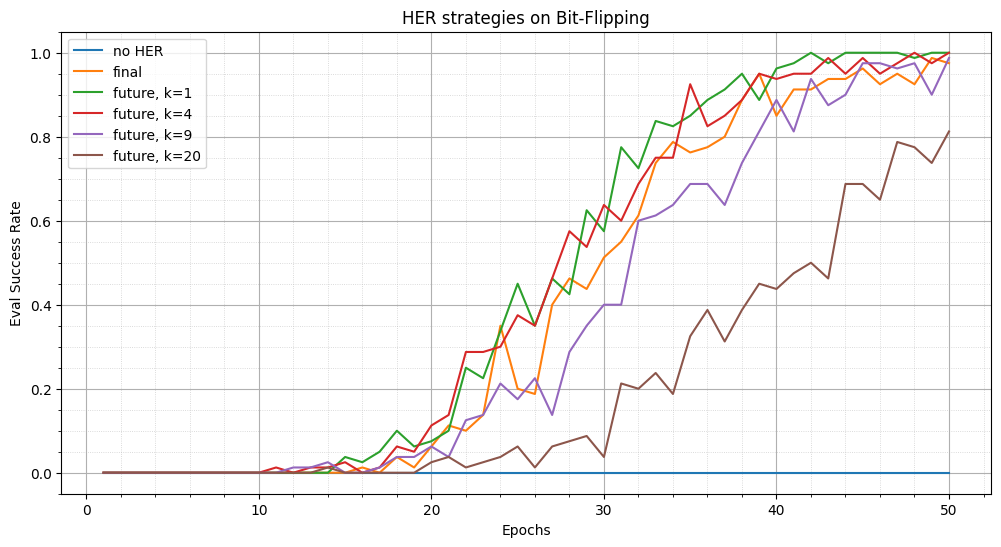

In [ ]:
plt.figure(figsize=(12, 6))
for name, trainer in trainers.items():
    rates = trainer.history["eval_success_rate"]
    plt.plot(range(1, len(rates) + 1), rates, label=name)
plt.xlabel('Epochs')
plt.ylabel('Eval Success Rate')
plt.legend()
plt.minorticks_on()
plt.grid()
plt.grid(which='major', linewidth=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.6, alpha=0.6)
plt.title('HER strategies on Bit-Flipping')

In [ ]:
df = pd.DataFrame(columns=["strategy", "success_rate", "episode_len"])
for name, trainer in trainers.items():
    print("Evaluating:", name)
    trainer.model.to(trainer.device)
    eval_metrics = trainer.evaluate(num_episodes=5000)
    df.loc[len(df)] = [name, eval_metrics["success_rate"], eval_metrics["avg_episode_len"]]
df

Evaluating: no HER


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [01:00<00:00, 83.13it/s] 


Evaluating: final


100%|██████████| 5000/5000 [00:29<00:00, 170.60it/s]


...

Evaluating: future, k=9


100%|██████████| 5000/5000 [00:28<00:00, 177.69it/s]


Evaluating: future, k=20


100%|██████████| 5000/5000 [00:34<00:00, 146.63it/s]


,strategy,success_rate,episode_len
0,no HER,0.0000,50.0000
1,final,0.9698,25.6600
2,"future, k=1",0.9940,25.0340
3,"future, k=4",0.9928,25.0746
4,"future, k=9",0.9672,25.7370
5,"future, k=20",0.7980,29.5566
